In [12]:
#import libraries
import pandas as pd
import re
from tqdm import tqdm
import matplotlib.pyplot as plt


In [16]:
teaser = pd.read_csv('./data/teaser_comments.csv')
debut = pd.read_csv('./data/debut_comments.csv')
teaser

,group,video_id,publishedAt,author,text,likeCount
0,LE SSERAFIM,A4twVWwOueU,2022-04-28T20:59:48Z,@MeelyBieber,Le sserafim motomamiiiiis,0
1,LE SSERAFIM,A4twVWwOueU,2022-04-28T20:58:54Z,@allygarska,<b>INDUSTRY TAKEOVER</b>,1
2,LE SSERAFIM,A4twVWwOueU,2022-04-28T20:58:04Z,@naswacitrarevalina6716,slayyy,1
3,LE SSERAFIM,A4twVWwOueU,2022-04-28T20:56:06Z,@venvop9674,we gonna wait another day for teaser 2 t-t I&#...,3
4,LE SSERAFIM,A4twVWwOueU,2022-04-28T20:55:45Z,@mess_mess_mess,わしはルセラフィムを応援し続ける覚悟があります,4
...,...,...,...,...,...,...
32700,YOUNITE,0qlRch-DJcc,2022-04-13T15:01:18Z,@Lavacakee,Third!!,0
32701,YOUNITE,0qlRch-DJcc,2022-04-13T15:01:18Z,@mrigdhaaaa,Giving first love vibes,3
32702,YOUNITE,0qlRch-DJcc,2022-04-13T15:01:06Z,@cyaharin,IT&#39;S SO CUTE!!,7
32703,YOUNITE,0qlRch-DJcc,2022-04-13T15:01:00Z,@joonielee03,🤍🤍🤍🤍🤍,0


In [17]:
sample_teaser = teaser.sample(1000, random_state=42)
sample_debut = debut.sample(1000, random_state=42)

## Does this comment contain words/patterns associated with Hype, Disappointment, Anger, Evaluation,...?

In [5]:
custom_regex_categories = {
    # Pre-debut hype / anticipation
    "anticipation_hype": [
        r"\bexcit\w*\b",              # excited, exciting, excitement
        r"\bhyp\w*\b",                # hype, hyped, hyping
        r"\bready\b",
        r"\bso\s+ready\b",
        r"\bcan'?t\s+wait\b",
        r"\bcannot\s+wait\b",
        r"\bwait\w*\b",               # wait, waiting
        r"\bsoon\b",
        r"\bcoming\s+soon\b",
        r"\bfinally\b",
        r"\bcount\s*down\b|\bcountdown\b",
        r"\bdebut\w*\b",
        r"\breleas\w*\b",             # release, released, releasing
        r"\bpremier\w*\b",
        r"\bteaser\w*\b",
        r"\btrailer\w*\b",
        r"\blook\w*\s+forward\b",
        r"\bneed\s+this\b",
        r"\babout\s+to\b",
        r"\blet'?s\s+go+\b",          # let's go, lets gooo
        r"\bgo+!\b",
    ],

    # Hope / expectation / imagined potential
    "hope_expectation": [
        r"\bhope\w*\b",               # hope, hopefully, hoping
        r"\bexpect\w*\b",             # expect, expected, expecting
        r"\bpotential\w*\b",
        r"\bpromis\w*\b",             # promise, promising
        r"\bfuture\b",
        r"\banticipat\w*\b",
        r"\bdeserv\w*\b",             # deserve, deserves, deserved
        r"\broot\w*\s+for\b",
        r"\bbeliev\w*\b",
        r"\bwish\w*\b",
        r"\bgonna\s+be\b",
        r"\bgoing\s+to\s+be\b",
        r"\bwill\s+be\b",
        r"\bshould\s+be\b",
    ],

    # Success / achievement language
    "achievement_success": [
        r"\bsuccess\w*\b",
        r"\bwin\w*\b",                # win, wins, winning
        r"\bviral\b",
        r"\bhit\b",
        r"\bpopular\b",
        r"\bfamous\b",
        r"\bbig\b",
        r"\bhuge\b",
        r"\btop\b",
        r"\bchart\w*\b",
        r"\brecord\w*\b",
        r"\bbreakthrough\b",
        r"\bdominat\w*\b",
        r"\biconic\b",
        r"\blegend\w*\b",
        r"\bdebut\s+of\s+the\s+year\b",
        r"\bnext\s+big\s+thing\b",
    ],

    # Fan support / community
    "fan_support": [
        r"\bsupport\w*\b",
        r"\bstan\w*\b",               # stan, stanning
        r"\bfans?\b",
        r"\bfandom\b",
        r"\bwe\b",
        r"\bus\b",
        r"\bour\b",
        r"\btogether\b",
        r"\bproud\b",
        r"\bproud\s+of\b",
        r"\blove\s+them\b",
        r"\bprotect\w*\b",
        r"\broot\w*\s+for\b",
        r"\bdeserv\w*\s+better\b",
        r"\blet'?s\s+go+\b",
        r"\bstream\w*\b",
        r"\bvote\w*\b",
        r"\bpromot\w*\b",
    ],

    # Joy / praise / social-media approval
    "joy_praise": [
        r"\blove+\b|\bluv+\b",
        r"\blov\w*\b",
        r"\blike\w*\b",
        r"\bamazing\b",
        r"\bgreat\b",
        r"\bgood\b",
        r"\bperfect\b",
        r"\bbeauti\w*\b",             # beautiful, beauty
        r"\bprett\w*\b",              # pretty
        r"\bstunn\w*\b",              # stunning
        r"\bslay+\w*\b",              # slay, slayy, slayed
        r"\bate\b|\beating\b",
        r"\bserv\w*\b",               # serve, served, serving
        r"\biconic\b",
        r"\bqueen\w*\b",
        r"\bking\w*\b",
        r"\bbest\b",
        r"\bfav\w*\b",                # fav, fave, favorite
        r"\bhappy\b",
        r"\bglad\b",
        r"\bfun\b",
        r"\bcool\b",
        r"\bfire\b",
        r"🔥+",
        r"❤️+|❤+|💕+|💖+|💗+|💓+|💘+",
    ],

    # Post-debut evaluation / realism
    "evaluation_realistic": [
        r"\bsong\w*\b",
        r"\bmusic\b",
        r"\btrack\w*\b",
        r"\balbum\w*\b",
        r"\bvocal\w*\b",
        r"\brap\w*\b",
        r"\bdanc\w*\b",
        r"\bperform\w*\b",
        r"\bstage\b",
        r"\bconcept\w*\b",
        r"\bvisual\w*\b",
        r"\boutfit\w*\b",
        r"\bstyl\w*\b",               # style, styling
        r"\blyric\w*\b",
        r"\bchorus\w*\b",
        r"\bverse\w*\b",
        r"\bbridge\w*\b",
        r"\bbeat\w*\b",
        r"\bproduction\b",
        r"\bquality\b",
        r"\bmv\b",
        r"\bvideo\w*\b",
        r"\bpromotion\w*\b",
        r"\bmarketing\b",
        r"\bline\s+distribution\b",
        r"\bscreen\s+time\b",
        r"\bedit\w*\b",
        r"\bchoreo\w*\b",             # choreo, choreography
    ],

    # Comparison / analytic reaction
    "comparison_analysis": [
        r"\bbetter\b",
        r"\bworse\b",
        r"\bbest\b",
        r"\bleast\b",
        r"\bmore\b",
        r"\bless\b",
        r"\bcompar\w*\b",
        r"\bsimilar\w*\b",
        r"\bdiffer\w*\b",
        r"\bsame\b",
        r"\bactually\b",
        r"\bhonestly\b",
        r"\bbecause\b",
        r"\breason\w*\b",
        r"\bmakes?\s+sense\b",
        r"\bdoesn'?t\s+make\s+sense\b",
        r"\bi\s+think\b",
        r"\bin\s+my\s+opinion\b",
        r"\bimo\b",
        r"\boverall\b",
    ],

    # Disappointment / letdown
    "disappointment": [
        r"\bdisappoint\w*\b",         # disappointed, disappointing
        r"\bunderwhelm\w*\b",
        r"\bboring\b",
        r"\bweak\b",
        r"\bbad\b",
        r"\bmid\b",
        r"\bmeh+\b",
        r"\bbland\b",
        r"\bforgettable\b",
        r"\black\w*\b",               # lack, lacking
        r"\bmiss\w*\b",               # miss, missed, missing
        r"\bwast\w*\b",               # waste, wasted
        r"\blet\s*down\b|\bletdown\b",
        r"\bnot\s+good\b",
        r"\bnot\s+great\b",
        r"\bnot\s+enough\b",
        r"\bcould\s+be\s+better\b",
        r"\bexpected\s+more\b",
        r"\bwanted\s+more\b",
    ],

    # Anger / blame, often company-directed
    "anger_blame": [
        r"\bangr\w*\b",               # angry, anger
        r"\bmad\b",
        r"\bannoy\w*\b",
        r"\bfrustrat\w*\b",
        r"\bhate\w*\b",
        r"\bterrible\b",
        r"\bawful\b",
        r"\bhorrible\b",
        r"\bruin\w*\b",
        r"\bsabotag\w*\b",
        r"\bmistreat\w*\b",
        r"\bunfair\b",
        r"\bfumbl\w*\b",              # fumble, fumbled
        r"\bmess\w*\b",
        r"\bbadly\b",
        r"\bcompany\b",
        r"\bmanagement\b",
        r"\blabel\b",
        r"\bagency\b",
        r"\bwhy\s+would\b",
        r"\bwhat\s+were\s+they\s+thinking\b",
        r"\bthey\s+failed\b",
        r"\bdeserv\w*\s+better\b",
        r"😡+|🤬+",
    ],

    # Anxiety / concern / risk
    "anxiety_concern": [
        r"\bworr\w*\b",               # worry, worried, worrying
        r"\bconcern\w*\b",
        r"\bscared\b",
        r"\bafraid\b",
        r"\bnervous\b",
        r"\banxious\b",
        r"\brisk\w*\b",
        r"\bflop\w*\b",
        r"\bfail\w*\b",
        r"\bfailure\b",
        r"\bproblem\w*\b",
        r"\bissue\w*\b",
        r"\bhope\s+not\b",
        r"\bwhat\s+if\b",
        r"\bnot\s+sure\b",
        r"\buncertain\b",
        r"\bdoubt\w*\b",
        r"😬+|😟+|😰+|😨+",
    ],
}


#### Text Cleaning:

In [6]:
# Clean up the text before matching
def normalize_social_text(text):
    if pd.isna(text):                                   # Check for NaN text values
        return ""

    text = str(text).lower()                            # Normalize text to lowercase
    text = text.replace("’", "'").replace("`", "'")     # Replace smart quotes with regular quotes
    text = re.sub(r"http\S+|www\S+", " ", text)         # Remove URLs
    text = re.sub(r"@\w+", " ", text)                   # Remove tagging
    text = re.sub(r"#", "", text)                       # Remove hashtags
    text = re.sub(r"\s+", " ", text).strip()            # Remove extra whitespace

    return text

#### Regex Matching:

In [7]:
# Count regex matches in a text
# For every text, match against all regex patterns
# Precondition
def count_regex_matches(text, regex_list):
    text = normalize_social_text(text)                   # Clean up the text before matching
    count = 0
    for regex in regex_list:
        # Create a list of all matches of regex in the text
        matches = re.findall(regex, text, flags=re.IGNORECASE)
        # Get the length of the list to see the number of matches
        count += len(matches)
    return count

In [ ]:
def add_all_emotion_count_columns(df, text_col, emotion_patterns):
    """
    Adds one count column for each emotion/theme category.

    Parameters:
    df: pandas DataFrame
    text_col: name of the column containing comments
    emotion_patterns: dictionary where
        key = emotion/category name
        value = list of regex patterns

    Example:
        emotion_patterns = {
            "anticipation_hype": anticipation_hype_list,
            "joy_praise": joy_praise_list,
            "anger_blame": anger_blame_list
        }

        teaser = add_all_emotion_count_columns(teaser, "text", emotion_patterns)
    """
    df = df.copy()
    for emotion_name, regex_list in emotion_patterns.items():
        new_col = emotion_name + "_count"

        df[new_col] = df[text_col].apply(
            lambda text: count_regex_matches(text, regex_list)
        )

    return df

In [22]:
add_all_emotion_count_columns(teaser, "text", custom_regex_categories)
add_all_emotion_count_columns(debut, "text", custom_regex_categories)

,group,video_id,publishedAt,author,text,likeCount,anticipation_hype_count,hope_expectation_count,achievement_success_count,fan_support_count,joy_praise_count,evaluation_realistic_count,comparison_analysis_count,disappointment_count,anger_blame_count,anxiety_concern_count
0,BOYNEXTDOOR,jizAb-SLvtM,2023-05-25T20:58:41Z,@bichinabichina4452,mid,0,0,0,0,0,0,0,0,1,0,0
1,BOYNEXTDOOR,jizAb-SLvtM,2023-05-25T20:57:41Z,@кирусядеточкина,"THEY&#39;RE SOOO SWEET I REALLY LOVE IT, GUYS ...",0,0,0,0,1,3,0,0,0,0,0
2,BOYNEXTDOOR,jizAb-SLvtM,2023-05-25T20:57:40Z,@Mama_Aqila01,Vibes nya prince bgt ga sih? Para prince yg la...,0,0,0,0,0,0,0,0,0,0,0
3,BOYNEXTDOOR,jizAb-SLvtM,2023-05-25T20:57:24Z,@leeknooooow,이 옵션을 선택하면 이 옵션을 선택할 수 있습니다♥️😍😅,1,0,0,0,0,0,0,0,0,0,0
4,BOYNEXTDOOR,jizAb-SLvtM,2023-05-25T20:57:08Z,@loove143_,0:14 &quot;representing KOZ&quot; I can&#39;t ...,146,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174573,ZEROBASEONE,trzeUClQIIg,2023-07-10T09:00:44Z,@mymymaxine,OMG,0,0,0,0,0,0,0,0,0,0,0
174574,ZEROBASEONE,trzeUClQIIg,2023-07-10T09:00:44Z,@nozvia,FIRST,0,0,0,0,0,0,0,0,0,0,0
174575,ZEROBASEONE,trzeUClQIIg,2023-07-10T09:00:43Z,@조용히해기무낙,0:01 아니 0:00 부터 헐 미쳤다 ㅠㅠㅠ 🎉🎉 제베원 데뷔 경축.. ㅠㅠ!!!...,1,0,0,0,0,1,0,0,0,0,0
174576,ZEROBASEONE,trzeUClQIIg,2023-07-10T09:00:43Z,@Kyo02,♡,0,0,0,0,0,0,0,0,0,0,0


#### Export the result to CSV File:

In [26]:
# Save the full comment-level datasets with emotion/theme count columns
teaser.to_csv(
    "./data/teaser_emotion_theme_counts.csv",
    index=False
)

debut.to_csv(
    "./data/debut_emotion_theme_counts.csv",
    index=False
)

#### Average Counts Table:

In [23]:
# Get all emotion/theme count columns
count_cols = [emotion + "_count" for emotion in custom_regex_categories.keys()]

# Average count per comment for each dataset
teaser_avg = teaser[count_cols].mean()
debut_avg = debut[count_cols].mean()

# Create comparison dataframe
emotion_summary = pd.DataFrame({
    "Teaser / Pre-debut": teaser_avg,
    "Debut / Post-debut": debut_avg
})

# Clean up row labels
emotion_summary.index = [
    col.replace("_count", "").replace("_", " ").title()
    for col in emotion_summary.index
]

emotion_summary

,Teaser / Pre-debut,Debut / Post-debut
Anticipation Hype,0.282587,0.185138
Hope Expectation,0.044733,0.044828
Achievement Success,0.029720,0.022139
Fan Support,0.080752,0.122163
Joy Praise,0.359700,0.526263
Evaluation Realistic,0.097141,0.251189
Comparison Analysis,0.031310,0.074580
Disappointment,0.005015,0.016497
Anger Blame,0.003975,0.014160
Anxiety Concern,0.002996,0.004817


### Data Visualization:

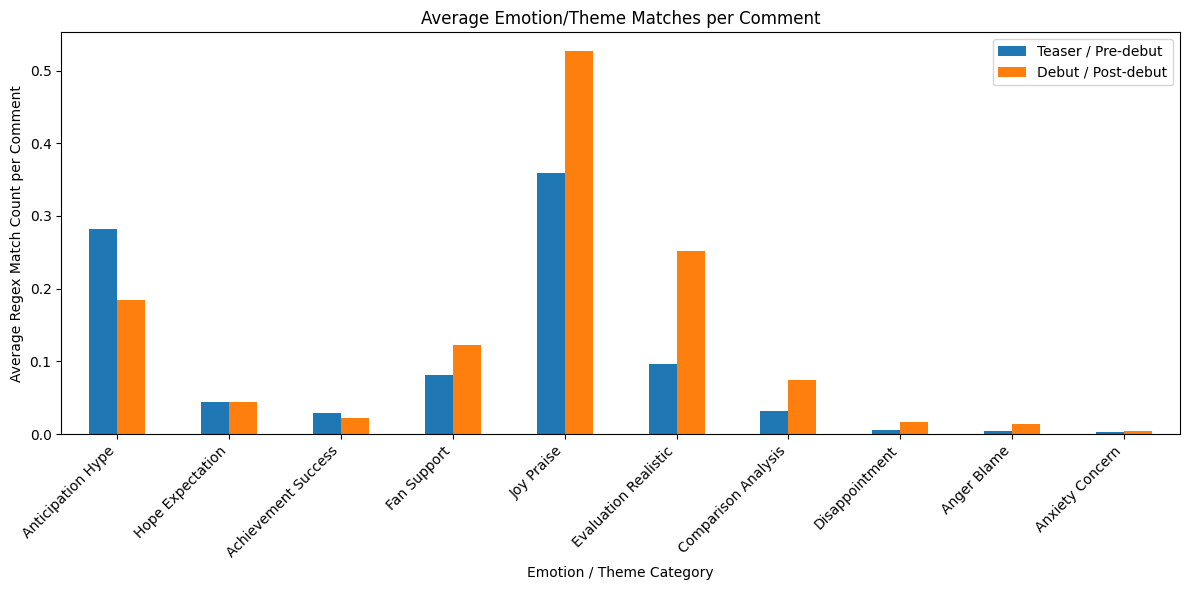

In [24]:
emotion_summary.plot(kind="bar", figsize=(12, 6))

plt.title("Average Emotion/Theme Matches per Comment")
plt.ylabel("Average Regex Match Count per Comment")
plt.xlabel("Emotion / Theme Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

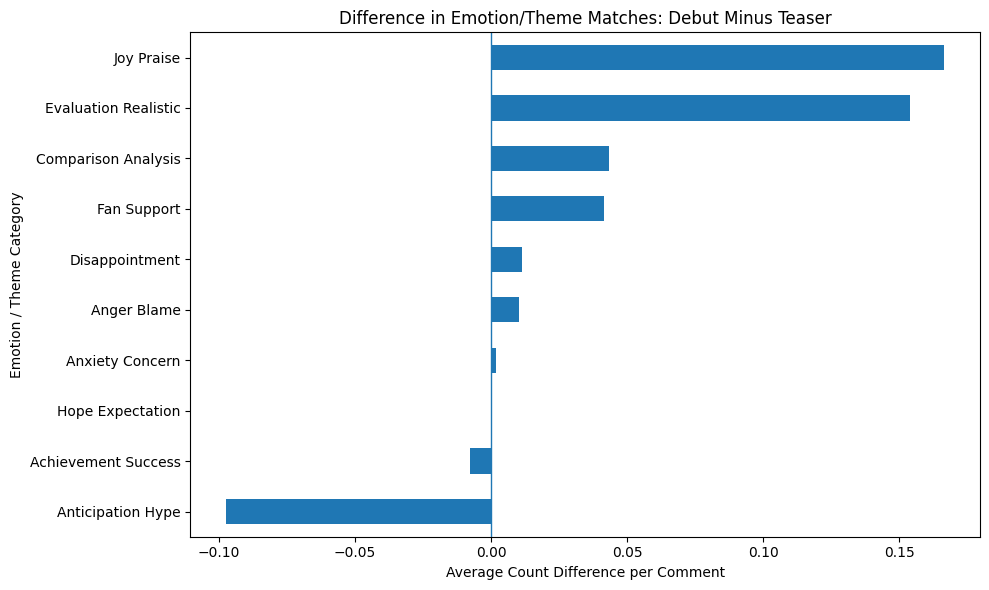

In [25]:
difference = emotion_summary["Debut / Post-debut"] - emotion_summary["Teaser / Pre-debut"]

difference = difference.sort_values()

difference.plot(kind="barh", figsize=(10, 6))

plt.title("Difference in Emotion/Theme Matches: Debut Minus Teaser")
plt.xlabel("Average Count Difference per Comment")
plt.ylabel("Emotion / Theme Category")
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()